In [ ]:
import tensorflow as tf
import sys

print("Versión de Python:", sys.version)
print("Versión de TensorFlow:", tf.__version__)
print("GPUs disponibles:", tf.config.list_physical_devices('GPU'))

Versión de Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Versión de TensorFlow: 2.20.0
GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!nvidia-smi

Tue Jun 16 18:29:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Fase 1 - Exploración del Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

ruta = "/content/drive/MyDrive/IA PROJECTS/CLASIFICADOR DE IMAGENES"

print(os.listdir(ruta))

['archive.zip', 'keras_tuner', 'model4_transfer_learning.keras', 'model4_transfer_learning_finetuned.keras']


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/IA PROJECTS/CLASIFICADOR DE IMAGENES/archive.zip"
extract_path = "/content/landscape_classification"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset descomprimido correctamente")

Dataset descomprimido correctamente


In [ ]:
DATASET_PATH = "/content/landscape_classification"

train_dir = f"{DATASET_PATH}/seg_train/seg_train"
test_dir = f"{DATASET_PATH}/seg_test/seg_test"
pred_dir = f"{DATASET_PATH}/seg_pred"

print("Clases en train:", os.listdir(train_dir))
print("Clases en test:", os.listdir(test_dir))

Clases en train: ['sea', 'forest', 'street', 'mountain', 'glacier', 'buildings']
Clases en test: ['sea', 'forest', 'street', 'mountain', 'glacier', 'buildings']


In [ ]:
for clase in os.listdir(train_dir):
    ruta_clase = os.path.join(train_dir, clase)
    num_imagenes = len(os.listdir(ruta_clase))
    print(f"{clase}: {num_imagenes}")

sea: 2274
forest: 2271
street: 2382
mountain: 2512
glacier: 2404
buildings: 2191


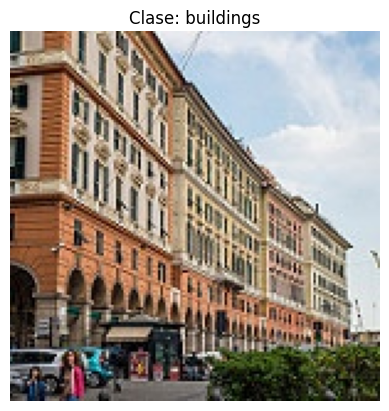

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

clase = random.choice(os.listdir(train_dir))

ruta_clase = os.path.join(train_dir, clase)

imagen_nombre = random.choice(os.listdir(ruta_clase))

ruta_imagen = os.path.join(ruta_clase, imagen_nombre)

img = Image.open(ruta_imagen)

plt.imshow(img)
plt.title(f"Clase: {clase}")
plt.axis("off")
plt.show()

In [ ]:
from PIL import Image

clase = os.listdir(train_dir)[0]

ruta_clase = os.path.join(train_dir, clase)

imagen = os.listdir(ruta_clase)[0]

ruta_imagen = os.path.join(ruta_clase, imagen)

img = Image.open(ruta_imagen)

print("Tamaño:", img.size)
print("Modo:", img.mode)

Tamaño: (150, 150)
Modo: RGB


División del dataset

In [ ]:
import tensorflow as tf

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(150, 150),
    batch_size=32
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(150, 150),
    batch_size=32
)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


In [ ]:
class_names = train_dataset.class_names
print(class_names)

for images, labels in train_dataset.take(1):
    print("Forma de las imágenes:", images.shape)
    print("Forma de las etiquetas:", labels.shape)
    print("Etiquetas:", labels.numpy())

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Forma de las imágenes: (32, 150, 150, 3)
Forma de las etiquetas: (32,)
Etiquetas: [1 5 5 1 1 3 0 4 1 2 3 4 5 5 5 4 2 5 4 2 5 0 4 2 4 0 5 4 1 1 2 3]


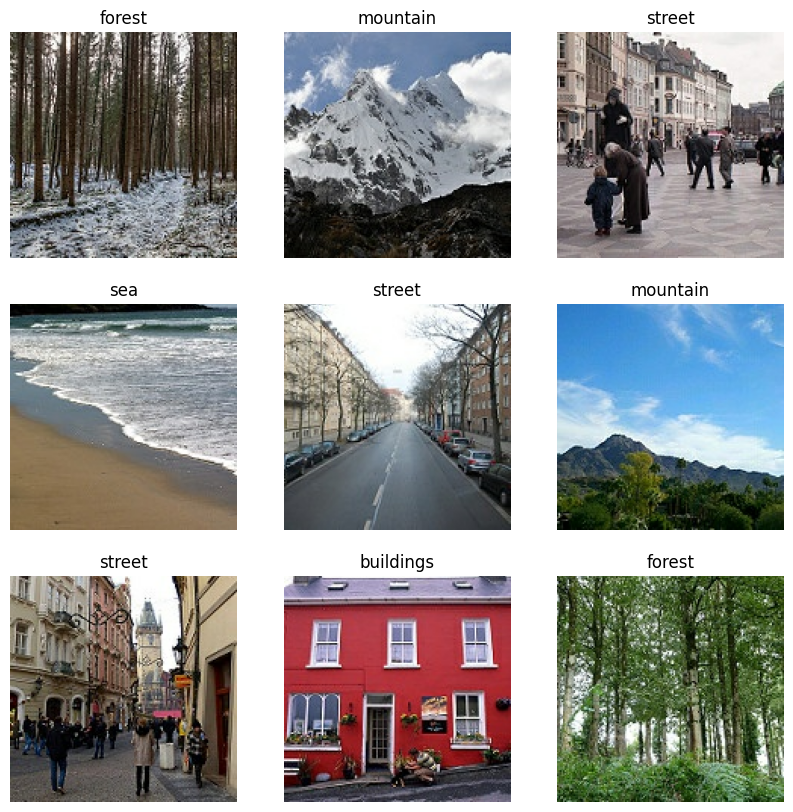

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

Reescalado

In [ ]:
#Crear herramienta de reescalado
normalization_layer = tf.keras.layers.Rescaling(1./255)

#Normalizar todos los batches de train_dataset
normalized_train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

#Normalizar todos los batches de validation dataset
normalized_validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

#Comprobación
for images, labels in normalized_train_dataset.take(1):

    print("Valor mínimo:", images.numpy().min())
    print("Valor máximo:", images.numpy().max())

Valor mínimo: 0.0
Valor máximo: 1.0


# Fase 2 - CNN BÁSICA

In [ ]:
model = tf.keras.Sequential([

    tf.keras.Input(shape=(150,150,3)),

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    ),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        6,
        activation='softmax'
    )

])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 175232)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    22,429,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,431,494 (85.57 MB)

 Trainable params: 22,431,494 (85.57 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    normalized_train_dataset,
    validation_data=normalized_validation_dataset,
    epochs=10
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.6079 - loss: 1.4390 - val_accuracy: 0.6500 - val_loss: 0.9616
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8005 - loss: 0.5866 - val_accuracy: 0.7010 - val_loss: 0.8734
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9004 - loss: 0.3143 - val_accuracy: 0.7128 - val_loss: 0.9401
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9605 - loss: 0.1560 - val_accuracy: 0.7352 - val_loss: 0.9940
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9772 - loss: 0.0981 - val_accuracy: 0.7580 - val_loss: 0.9575
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9898 - loss: 0.0557 - val_accuracy: 0.7388 - val_loss: 1.1735
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.9925 - loss: 0.0423 - val_accuracy: 0.7363 - val_loss: 1.2783
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9912 - loss: 0.0442 - val_ac

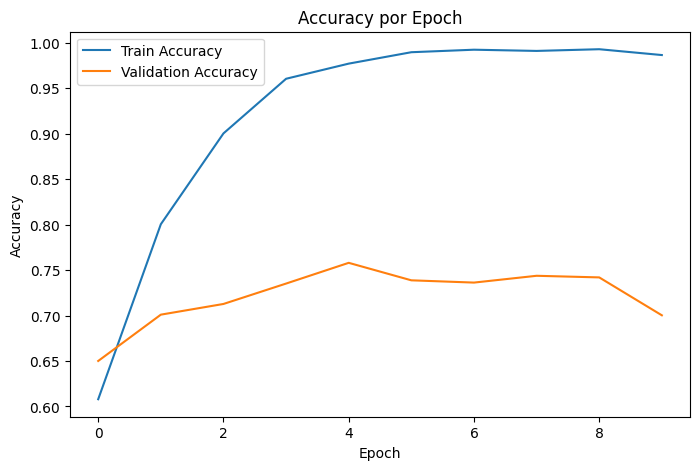

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy por Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

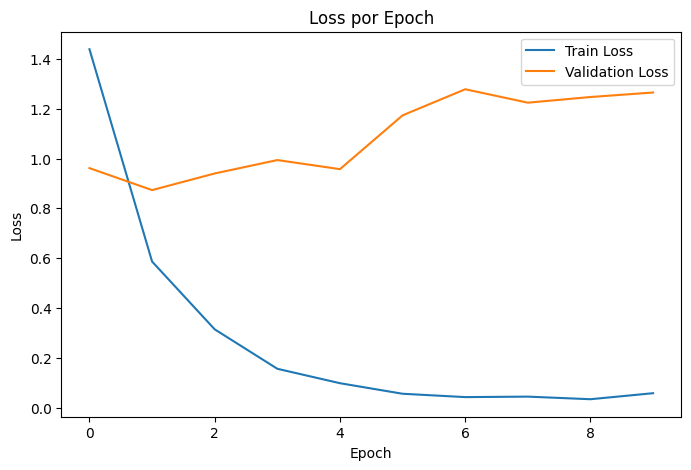

In [ ]:
# Loss
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss por Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Fase 3 - CNN AVANZADA

In [ ]:
model2 = tf.keras.Sequential([

    tf.keras.Input(shape=(150,150,3)),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),

    tf.keras.layers.Dense(6, activation='softmax')
])

In [ ]:
model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 146, 146, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 69, 69, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,003,892 (49.61 MB)

 Trainable params: 4,334,630 (16.54 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,669,262 (33.07 MB)

In [ ]:
history2 = model2.fit(
    normalized_train_dataset,
    validation_data=normalized_validation_dataset,
    epochs=10
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 87ms/step - accuracy: 0.5858 - loss: 1.0209 - val_accuracy: 0.6625 - val_loss: 0.8381
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 22s 56ms/step - accuracy: 0.7224 - loss: 0.7176 - val_accuracy: 0.6650 - val_loss: 1.0358
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.8000 - loss: 0.5431 - val_accuracy: 0.7651 - val_loss: 0.6324
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 22s 58ms/step - accuracy: 0.8465 - loss: 0.4206 - val_accuracy: 0.7865 - val_loss: 0.6943
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.8946 - loss: 0.2959 - val_accuracy: 0.7954 - val_loss: 0.7075
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.9291 - loss: 0.2019 - val_accuracy: 0.8086 - val_loss: 0.8345
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.9505 - loss: 0.1467 - val_accuracy: 0.7445 - val_loss: 1.1059
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.9679 - loss: 0.0971 - 

# Fase 3 - KERAS TUNER

In [ ]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.5 MB/s eta 0:00:00


In [ ]:
import keras_tuner as kt
import tensorflow as tf

In [ ]:
def build_model(hp):

    model = tf.keras.Sequential([

        tf.keras.Input(shape=(150, 150, 3)),

        # Bloque 1
        tf.keras.layers.Conv2D(
            filters=hp.Choice("conv1_filters", [32, 64]),
            kernel_size=(3,3),
            activation=hp.Choice("activation", ["relu", "tanh"])
        ),

        tf.keras.layers.Conv2D(
            filters=hp.Choice("conv2_filters", [32, 64]),
            kernel_size=(3,3),
            activation=hp.Choice("activation", ["relu", "tanh"])
        ),

        tf.keras.layers.MaxPooling2D((2,2)),


        # Bloque 2
        tf.keras.layers.Conv2D(
            filters=hp.Choice("conv3_filters", [64, 128]),
            kernel_size=(3,3),
            activation=hp.Choice("activation", ["relu", "tanh"])
        ),

        tf.keras.layers.Conv2D(
            filters=hp.Choice("conv4_filters", [64, 128]),
            kernel_size=(3,3),
            activation=hp.Choice("activation", ["relu", "tanh"])
        ),

        tf.keras.layers.MaxPooling2D((2,2)),


        # Bloque 3
        tf.keras.layers.Conv2D(
            filters=hp.Choice("conv5_filters", [128, 256]),
            kernel_size=(3,3),
            activation=hp.Choice("activation", ["relu", "tanh"])
        ),

        tf.keras.layers.MaxPooling2D((2,2)),


        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(
            hp.Choice("dense_units", [64, 128, 256]),
            activation=hp.Choice("activation", ["relu", "tanh"])
        ),

        tf.keras.layers.Dropout(
            hp.Choice("dropout", [0.0, 0.3, 0.5])
        ),

        tf.keras.layers.Dense(6, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
tuner2 = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=10,
    overwrite=True,
    directory="/content/drive/MyDrive/IA PROJECTS/CLASIFICADOR DE IMAGENES/keras_tuner",
    project_name="model2_tuned"
)

In [ ]:
tuner2.search(
    normalized_train_dataset,
    validation_data=normalized_validation_dataset,
    epochs=10
)

Trial 10 Complete [00h 04m 50s]
val_accuracy: 0.8321453928947449

Best val_accuracy So Far: 0.8321453928947449
Total elapsed time: 00h 59m 04s


In [ ]:
best_hps = tuner2.get_best_hyperparameters(num_trials=1)[0]

print("===== MEJORES HIPERPARÁMETROS =====")
print("Conv1 Filters :", best_hps.get("conv1_filters"))
print("Conv2 Filters :", best_hps.get("conv2_filters"))
print("Conv3 Filters :", best_hps.get("conv3_filters"))
print("Conv4 Filters :", best_hps.get("conv4_filters"))
print("Conv5 Filters :", best_hps.get("conv5_filters"))
print("Dense Units   :", best_hps.get("dense_units"))
print("Dropout       :", best_hps.get("dropout"))
print("Activation    :", best_hps.get("activation"))

===== MEJORES HIPERPARÁMETROS =====
Conv1 Filters : 32
Conv2 Filters : 32
Conv3 Filters : 64
Conv4 Filters : 128
Conv5 Filters : 128
Dense Units   : 256
Dropout       : 0.5
Activation    : relu


In [ ]:
best_model = tuner2.hypermodel.build(best_hps)

In [ ]:
history3 = best_model.fit(
    normalized_train_dataset,
    validation_data=normalized_validation_dataset,
    epochs=10
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 36s 83ms/step - accuracy: 0.5626 - loss: 1.0767 - val_accuracy: 0.6397 - val_loss: 0.9040
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 68ms/step - accuracy: 0.6765 - loss: 0.8313 - val_accuracy: 0.7334 - val_loss: 0.7056
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.7536 - loss: 0.6667 - val_accuracy: 0.7847 - val_loss: 0.5723
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 67ms/step - accuracy: 0.7958 - loss: 0.5607 - val_accuracy: 0.8026 - val_loss: 0.5673
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 24s 69ms/step - accuracy: 0.8291 - loss: 0.4686 - val_accuracy: 0.8236 - val_loss: 0.5311
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.8610 - loss: 0.3866 - val_accuracy: 0.8108 - val_loss: 0.5851
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.8836 - loss: 0.3346 - val_accuracy: 0.8239 - val_loss: 0.6106
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.9030 - loss: 0.2700 - 

# Fase 4 - TRANSFER LEARNING

In [ ]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(150, 150, 3),
    include_top=False,
    weights="imagenet"
)

/tmp/ipykernel_1652/3851355182.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [ ]:
base_model.trainable = False

In [ ]:
model4 = tf.keras.Sequential([

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.Dense(6, activation="softmax")

])

model4.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history4 = model4.fit(
    normalized_train_dataset,
    validation_data=normalized_validation_dataset,
    epochs=10
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 59s 113ms/step - accuracy: 0.8674 - loss: 0.3706 - val_accuracy: 0.8899 - val_loss: 0.3091
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9096 - loss: 0.2470 - val_accuracy: 0.9048 - val_loss: 0.2715
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9242 - loss: 0.2047 - val_accuracy: 0.9009 - val_loss: 0.2767
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9343 - loss: 0.1718 - val_accuracy: 0.9048 - val_loss: 0.2829
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9457 - loss: 0.1419 - val_accuracy: 0.9031 - val_loss: 0.2991
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9536 - loss: 0.1247 - val_accuracy: 0.9059 - val_loss: 0.2866
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9613 - loss: 0.1052 - val_accuracy: 0.9041 - val_loss: 0.3053
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9668 - loss: 0.0904 - val

In [ ]:
model4.save(
    "/content/drive/MyDrive/IA PROJECTS/CLASIFICADOR DE IMAGENES/model4_transfer_learning.keras"
)

In [ ]:
from tensorflow.keras.models import load_model

ruta_modelo4 = "/content/drive/MyDrive/IA PROJECTS/CLASIFICADOR DE IMAGENES/model4_transfer_learning.keras"

model4 = load_model(ruta_modelo4)
model4.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,752,212 (10.50 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 329,486 (1.26 MB)

FINE-TUNING

In [ ]:
base_model = model4.layers[0]

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
model4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model4.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 1,691,142 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [ ]:
history4_finetuning = model4.fit(
    normalized_train_dataset,
    validation_data=normalized_validation_dataset,
    epochs=5
)

Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 68s 119ms/step - accuracy: 0.8520 - loss: 0.4651 - val_accuracy: 0.8977 - val_loss: 0.3751
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.9078 - loss: 0.2589 - val_accuracy: 0.9059 - val_loss: 0.3522
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9304 - loss: 0.1911 - val_accuracy: 0.9052 - val_loss: 0.3376
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9367 - loss: 0.1586 - val_accuracy: 0.9041 - val_loss: 0.3270
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9507 - loss: 0.1323 - val_accuracy: 0.9052 - val_loss: 0.3229


In [ ]:
model4.save(
    "/content/drive/MyDrive/IA PROJECTS/CLASIFICADOR DE IMAGENES/model4_transfer_learning_finetuned.keras"
)

# Fase 5 - DATA AUGMENTATION

In [ ]:
from tensorflow.keras.models import load_model

model5 = load_model(
    "/content/drive/MyDrive/IA PROJECTS/CLASIFICADOR DE IMAGENES/model4_transfer_learning.keras"
)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode="sparse",
    subset="training",
    seed=42
)

validation_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode="sparse",
    subset="validation",
    seed=42
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.


In [ ]:
history5 = model5.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 137s 335ms/step - accuracy: 0.8434 - loss: 0.4399 - val_accuracy: 0.8634 - val_loss: 0.3686
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 91s 260ms/step - accuracy: 0.8676 - loss: 0.3561 - val_accuracy: 0.8802 - val_loss: 0.3277
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 87s 249ms/step - accuracy: 0.8766 - loss: 0.3319 - val_accuracy: 0.8759 - val_loss: 0.3432
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 89s 252ms/step - accuracy: 0.8791 - loss: 0.3177 - val_accuracy: 0.8680 - val_loss: 0.3460
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 92s 260ms/step - accuracy: 0.8835 - loss: 0.3027 - val_accuracy: 0.8773 - val_loss: 0.3303
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 88s 249ms/step - accuracy: 0.8869 - loss: 0.2956 - val_accuracy: 0.8752 - val_loss: 0.3406
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 91s 258ms/step - accuracy: 0.8894 - loss: 0.3013 - val_accuracy: 0.8805 - val_loss: 0.3248
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 87s 248ms/step - accuracy: 0.8894 - loss: 

# ANEXO - PROBANDO DATA AUGMENTATION EN MODELO 2 CON MEJORES HIPERPARÁMETROS

In [ ]:
import tensorflow as tf
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
import os

os.listdir("/content/drive/MyDrive/IA PROJECTS/CLASIFICADOR DE IMAGENES")

['archive.zip',
 'keras_tuner',
 'model4_transfer_learning.keras',
 'model4_transfer_learning_finetuned.keras']

In [ ]:
import tensorflow as tf
import keras_tuner as kt

tuner2 = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=10,
    overwrite=False,
    directory="/content/drive/MyDrive/IA PROJECTS/CLASIFICADOR DE IMAGENES/keras_tuner",
    project_name="model2_tuned"
)

Reloading Tuner from /content/drive/MyDrive/IA PROJECTS/CLASIFICADOR DE IMAGENES/keras_tuner/model2_tuned/tuner0.json


In [ ]:
model3 = tuner2.get_best_models(num_models=1)[0]

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
model3.save(
    "/content/drive/MyDrive/IA PROJECTS/CLASIFICADOR DE IMAGENES/model3_keras_tuner.keras"
)

In [ ]:
model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 146, 146, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 73, 73, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 69, 69, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 34, 34, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,640,486 (32.96 MB)

 Trainable params: 8,640,486 (32.96 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

model3_aug = load_model(
    "/content/drive/MyDrive/IA PROJECTS/CLASIFICADOR DE IMAGENES/model3_keras_tuner.keras"
)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 30 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode="sparse",
    subset="training",
    seed=42
)

validation_generator = validation_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode="sparse",
    subset="validation",
    seed=42
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.


In [ ]:
model3_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

history_model3_aug = model3_aug.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 87s 233ms/step - accuracy: 0.8080 - loss: 0.5967 - val_accuracy: 0.9226 - val_loss: 0.2578
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 78s 223ms/step - accuracy: 0.8189 - loss: 0.5132 - val_accuracy: 0.9201 - val_loss: 0.2454
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 81s 232ms/step - accuracy: 0.8276 - loss: 0.4944 - val_accuracy: 0.9105 - val_loss: 0.2809
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 80s 227ms/step - accuracy: 0.8378 - loss: 0.4640 - val_accuracy: 0.9141 - val_loss: 0.2640


In [ ]:
model3_aug = load_model(
    "/content/drive/MyDrive/IA PROJECTS/CLASIFICADOR DE IMAGENES/model3_keras_tuner.keras"
)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode="sparse",
    subset="training",
    seed=42
)

Found 11230 images belonging to 6 classes.


In [ ]:
model3_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

history_model3_aug_riguroso = model3_aug.fit(
    train_generator,
    validation_data=normalized_validation_dataset,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 83s 224ms/step - accuracy: 0.8043 - loss: 0.5846 - val_accuracy: 0.8311 - val_loss: 0.5170
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 75s 213ms/step - accuracy: 0.8236 - loss: 0.5076 - val_accuracy: 0.8286 - val_loss: 0.5142
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 75s 215ms/step - accuracy: 0.8241 - loss: 0.4889 - val_accuracy: 0.8332 - val_loss: 0.4884
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 75s 213ms/step - accuracy: 0.8312 - loss: 0.4840 - val_accuracy: 0.8325 - val_loss: 0.4796
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 75s 212ms/step - accuracy: 0.8366 - loss: 0.4623 - val_accuracy: 0.8311 - val_loss: 0.5077
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 74s 211ms/step - accuracy: 0.8377 - loss: 0.4530 - val_accuracy: 0.8411 - val_loss: 0.4552
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 75s 214ms/step - accuracy: 0.8435 - loss: 0.4492 - val_accuracy: 0.8535 - val_loss: 0.4204
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 76s 216ms/step - accuracy: 0.8499 - loss: 0